# Attrition Predictive Pipeline - Interactive Testing

This notebook allows you to interactively run the end-to-end attrition pipeline. It follows standard modular practices for Data (Chronon-style) and Models (SageMaker-ready).

## ⚙️ Initial Setup

In [1]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import get_snowpark_session, run_pipeline_sql, load_training_data
from feature_engineering import AttritionFeatureEngineer
from train_model import train_all_models

print("✅ Libraries loaded.")

✅ Libraries loaded.


## ❄️ 1. Snowflake Connectivity & Data Engineering
First, we establish a Snowpark session. This session will be used to execute the 4-stage SQL waterfall.

In [2]:
session = get_snowpark_session()
print(f"Connected to: {session.get_current_account()}")

INFO:snowflake.connector.connection:Snowflake Connector for Python Version: 3.14.0, Python Version: 3.8.0, Platform: Windows-10-10.0.26100-SP0
INFO:snowflake.connector.connection:Connecting to GLOBAL Snowflake domain
INFO:snowflake.connector.connection:This connection is in OCSP Fail Open Mode. TLS Certificates would be checked for validity and revocation status. Any other Certificate Revocation related exceptions or OCSP Responder failures would be disregarded in favor of connectivity.
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseFailedToConnectCacheServer|OCSPResponseFetchException', 'sfcPeerHost': 'bqa07840.us-west-2.privatelink.snowflakecomputing.com', 'certId': 'MEcwBwYFKw4DAhoEFKfEuLPcW7VYHqfX8TrFafVvSNeJBBR0hYDAZsffN97PvSk3qgMdvu3NFwIQDTE9kLe5RBNwiIraRbCgwQ==', 'ocspRequestBase64': 'ME8wTTBLMEkwRzAHBgUrDgMCGgQUp8S4s9xbtVgep9fxOsVp9W9I14kEFHSFgMBmx9833s+9KTeqAx2+7c0XAhANMT2Qt7lEE3CIitpFsKDB', 'ocspResponde

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://myapps.wexinc.com/app/snowflake/exkaea789nRrm6HV7357/sso/saml?SAMLRequest=pZPNbuIwFIVfJfKsEzuBKWARKgbEEIlpKYRK7c5NDHhw7ODrEHj7cfgZtYt2UymLxD7X37n3OP37YyG9AzcgtIpRGBDkcZXpXKhNjFbpxO8iDyxTOZNa8RidOKD7QR9YIUs6rOxWLfi%2B4mA9d5AC2mzEqDKKagYCqGIFB2ozuhz%2BmdEoIJQBcGMdDl1LchCOtbW2pBjXdR3UrUCbDY4IIZj0sFM1kh%2FoHaL8mlEabXWm5a3k6Hr6BBFi0m4QTuEI82vhL6EuI%2FiK8nYRAZ2m6dyfPy5T5A1v3Y20gqrgZsnNQWR8tZhdDIBz8LZnpNNtk6ACv3az86OgNOLALJdC7QJQul5LtuOZLsrKOkTg3vCa51jqjXCDS8YxKnciP4xEW%2F1%2B3CRPL1r%2F3W4e0qzYajIbMTLW2apenabVy%2BQp2b%2BuMuQ932KOmpgTgIonqgnXuiUS3fnEPa00bNOQ0LAVRL3WK%2FLGzqBQzJ4rbx0UJ1aWENT8KFR2due%2B8X%2FjmB93jLNOt6cWpribPndaPzsYQOMmPHS5P%2FTswAy%2BNZU%2Bfn%2FU9V4%2BuKiS8VxLkZ28iTYFs58nGQbheUXk%2FvospbxgQg7z3HAAl6iUuh4Z7nzEyJqKIzy4UD%2F%2BA

INFO:snowflake.snowpark.session:Snowpark Session information: 
"version" : 1.22.1,
"python.version" : 3.8.0,
"python.connector.version" : 3.14.0,
"python.connector.session.id" : 14816483404981214,
"os.name" : Windows

INFO:data_loader:Successfully connected to Snowflake as W515059


Connected to: "bqa07840"


In [3]:
# Execute the SQL Waterfall (C1 -> C2 -> C3 -> C4 -> C5)
# Note: This might take a few minutes depending on your warehouse size.
run_pipeline_sql(session, sql_dir="../sql")

INFO:data_loader:Executing c1_target_variable.sql...
INFO:data_loader:Finished c1_target_variable.sql
INFO:data_loader:Executing c2_account_features.sql...
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseFailedToConnectCacheServer|OCSPResponseFetchException', 'sfcPeerHost': 'bqa07840.us-west-2.privatelink.snowflakecomputing.com', 'certId': 'MEcwBwYFKw4DAhoEFKfEuLPcW7VYHqfX8TrFafVvSNeJBBR0hYDAZsffN97PvSk3qgMdvu3NFwIQDTE9kLe5RBNwiIraRbCgwQ==', 'ocspRequestBase64': 'ME8wTTBLMEkwRzAHBgUrDgMCGgQUp8S4s9xbtVgep9fxOsVp9W9I14kEFHSFgMBmx9833s+9KTeqAx2+7c0XAhANMT2Qt7lEE3CIitpFsKDB', 'ocspResponderURL': 'http://ocsp.digicert.com', 'errorMessage': "254003: 254003: Could not fetch OCSP Response from server. Considerchecking your whitelists : Exception - ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))", 'insecureMode': False, 'failOpen': True

## 📊 2. Data Inspection
Load the master table into a Pandas DataFrame for exploration.

In [4]:
snowpark_df = load_training_data(session)
# df = snowpark_df.limit(10000).to_pandas()
df = snowpark_df.limit(2000000).to_pandas()

print(df.columns)
print(f"Retrieved {len(df)} sample rows.")
df.head()

INFO:data_loader:Loading data from WORKSPACE.digitalda_stage.ML_Attrition_Master_Table...
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseFailedToConnectCacheServer|OCSPResponseFetchException', 'sfcPeerHost': 'bqa07840.us-west-2.privatelink.snowflakecomputing.com', 'certId': 'MEcwBwYFKw4DAhoEFKfEuLPcW7VYHqfX8TrFafVvSNeJBBR0hYDAZsffN97PvSk3qgMdvu3NFwIQDTE9kLe5RBNwiIraRbCgwQ==', 'ocspRequestBase64': 'ME8wTTBLMEkwRzAHBgUrDgMCGgQUp8S4s9xbtVgep9fxOsVp9W9I14kEFHSFgMBmx9833s+9KTeqAx2+7c0XAhANMT2Qt7lEE3CIitpFsKDB', 'ocspResponderURL': 'http://ocsp.digicert.com', 'errorMessage': "254003: 254003: Could not fetch OCSP Response from server. Considerchecking your whitelists : Exception - ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))", 'insecureMode': False, 'failOpen': True, 'cacheEnabled': True, 'cacheHit': False}
 {'driver': 'PythonConn

Index(['ORG_URI', 'COHORT_MONTH', 'HISTORICAL_ATTRITION_DECISION',
       'TARGET_CURRENT_MONTH', 'FLIP_DATE', 'ATTRITION_DATE',
       'STATUS_ACCOUNT_COUNT', 'STATUS_ACTIVE_COUNT', 'TARGET_3M', 'TARGET_6M',
       ...
       'ENT_CASE_FEES_COUNT_LAG1', 'ENT_CASE_FEES_COUNT_LAG2',
       'ENT_CASE_DISPUTES_COUNT_LAG1', 'ENT_CASE_DISPUTES_COUNT_LAG2',
       'ENT_CASE_PUMP_ISSUES_COUNT_LAG1', 'ENT_CASE_PUMP_ISSUES_COUNT_LAG2',
       'ENT_CASE_TOTAL_EXCL_TERM_COUNT_LAG1',
       'ENT_CASE_TOTAL_EXCL_TERM_COUNT_LAG2', 'ENT_CASE_OTHER_COUNT_LAG1',
       'ENT_CASE_OTHER_COUNT_LAG2'],
      dtype='object', length=121)
Retrieved 2000000 sample rows.


,ORG_URI,COHORT_MONTH,HISTORICAL_ATTRITION_DECISION,TARGET_CURRENT_MONTH,FLIP_DATE,ATTRITION_DATE,STATUS_ACCOUNT_COUNT,STATUS_ACTIVE_COUNT,TARGET_3M,TARGET_6M,...,ENT_CASE_FEES_COUNT_LAG1,ENT_CASE_FEES_COUNT_LAG2,ENT_CASE_DISPUTES_COUNT_LAG1,ENT_CASE_DISPUTES_COUNT_LAG2,ENT_CASE_PUMP_ISSUES_COUNT_LAG1,ENT_CASE_PUMP_ISSUES_COUNT_LAG2,ENT_CASE_TOTAL_EXCL_TERM_COUNT_LAG1,ENT_CASE_TOTAL_EXCL_TERM_COUNT_LAG2,ENT_CASE_OTHER_COUNT_LAG1,ENT_CASE_OTHER_COUNT_LAG2
0,entities/2yeFke4,2023-08-01,Healthy,0.0,None,None,3.0,1.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,entities/2yeFke4,2023-09-01,Healthy,0.0,None,None,3.0,1.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,entities/2yeFke4,2023-10-01,Healthy,0.0,None,None,3.0,1.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,entities/2yeFke4,2023-11-01,Healthy,0.0,None,None,3.0,1.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,entities/2yeFke4,2023-12-01,Healthy,0.0,None,None,3.0,1.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


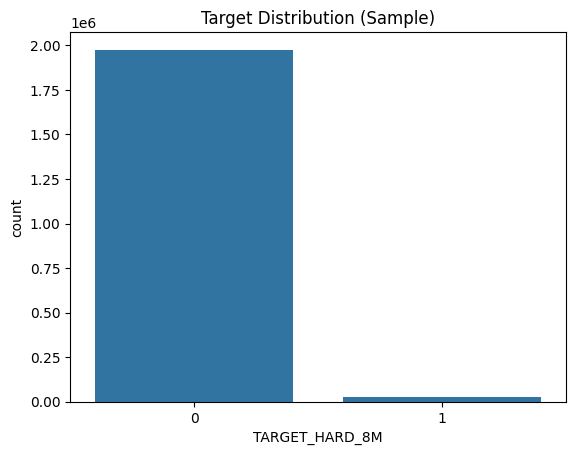

In [5]:
# Target Balance Check
sns.countplot(x='TARGET_HARD_8M', data=df)
plt.title('Target Distribution (Sample)')
plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


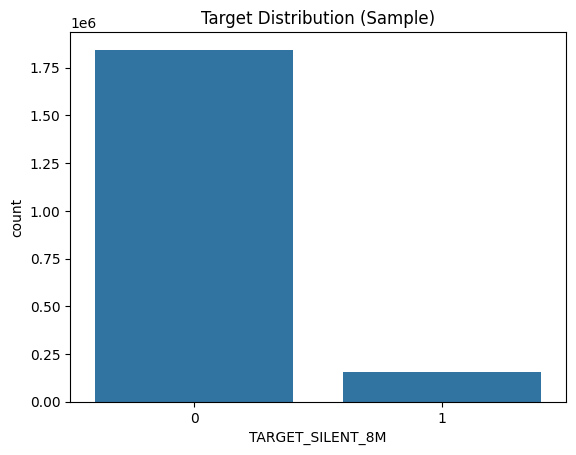

In [9]:
# Target Balance Check
sns.countplot(x='TARGET_SILENT_8M', data=df)
plt.title('Target Distribution (Sample)')
plt.show()

## Section 2.5: Multi-Horizon Feature Profiling

In [6]:
from feature_profiling import MultiHorizonProfiler
import logging

# 1. Initialize the profiler
pd.set_option('display.max_rows', None)
profiler = MultiHorizonProfiler(targets=['TARGET_HARD_8M', 'TARGET_SILENT_8M'])

# 2. Retrieve a 1% random sample from Snowflake
print("Retrieving sample from Snowflake (this may take a minute)...")
snowpark_df = load_training_data(session)
sample_df = snowpark_df.sample(0.01).to_pandas()
sample_df.columns = [c.upper() for c in sample_df.columns]

# 3. Run profiling (feature_list is now optional and auto-detected)
# This will calculate IV, PSI, and Mutual Information
results_df = profiler.run_profiling(sample_df)

# 4. Display results for 8-Month Horizon
print("\n--- Top Features by IV (Information Value) for 8-Month Horizon HARD ---")
# Note: The column name in the results is 'Total_IV'
display(results_df[results_df['Horizon'] == 'TARGET_HARD_8M'].sort_values('Total_IV', ascending=False))
print("\n--- Top Features by IV (Information Value) for 8-Month Horizon SILENT ---")
display(results_df[results_df['Horizon'] == 'TARGET_SILENT_8M'].sort_values('Total_IV', ascending=False))

# 5. Horizon Comparison
if not results_df.empty:
    pivot_iv = results_df.pivot(index='Feature', columns='Horizon', values='Total_IV')
    print("\n--- IV Comparison across Horizons (Top 50) ---")
    display(pivot_iv.sort_values('TARGET_HARD_8M', ascending=False).head(50))
    display(pivot_iv.sort_values('TARGET_SILENT_8M', ascending=False).head(50))


INFO:data_loader:Loading data from WORKSPACE.digitalda_stage.ML_Attrition_Master_Table...


Retrieving sample from Snowflake (this may take a minute)...


ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt. Consider checking for OCSP URLs being blocked
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseCacheDownloadFailed|OCSPResponseFetchFailure', 'sfcPeerHost': 'sfc-prod2-ds1-18-customer-stage.s3.us-west-2.amazonaws.com', 'certId': 'MEcwBwYFKw4DAhoEFKF1UQWdIRDSAbkIG3Mzjxw8x71fBBSBuA5jiokSGOX6OztQlZ/m5ZAThQIQCd8qwlDJcSCxEfK48eVFkQ==', 'ocspRequestBase64': 'ME8wTTBLMEkwRzAHBgUrDgMCGgQUoXVRBZ0hENIBuQgbczOPHDzHvV8EFIG4DmOKiRIY5fo7O1CVn+blkBOFAhAJ3yrCUMlxILER8rjx5UWR', 'ocspResponderURL': 'http://ocsp.


--- Top Features by IV (Information Value) for 8-Month Horizon HARD ---


,Feature,Horizon,Total_IV,Total_PSI,Max_Lift,Mutual_Information,Missing_Pct
45,ENT_CASE_PUMP_ISSUES_COUNT,TARGET_HARD_8M,7.614384,0,9.999439,0.000000,0.000000
44,ENT_CASE_DISPUTES_COUNT,TARGET_HARD_8M,7.614384,0,9.999439,0.000000,0.000000
41,ENT_CASE_APPLICATION_FRAUD_COUNT,TARGET_HARD_8M,7.614384,0,9.999439,0.000000,0.000000
42,ENT_CASE_CLAIMS_COUNT,TARGET_HARD_8M,7.614384,0,9.999439,0.000465,0.000000
43,ENT_CASE_FEES_COUNT,TARGET_HARD_8M,7.614384,0,9.999439,0.000608,0.000000
38,ENT_CASE_PAYMENT_BILLING_REC_COUNT,TARGET_HARD_8M,7.583846,0,9.996521,0.000926,0.000000
80,ENT_CASE_FEES_COUNT_LAG1,TARGET_HARD_8M,7.570663,0,9.797874,0.000380,0.041339
78,ENT_CASE_CLAIMS_COUNT_LAG1,TARGET_HARD_8M,7.570663,0,9.797874,0.000000,0.041339
76,ENT_CASE_APPLICATION_FRAUD_COUNT_LAG1,TARGET_HARD_8M,7.570663,0,9.797874,0.000000,0.041339
82,ENT_CASE_DISPUTES_COUNT_LAG1,TARGET_HARD_8M,7.570663,0,9.797874,0.000000,0.041339



--- Top Features by IV (Information Value) for 8-Month Horizon SILENT ---


,Feature,Horizon,Total_IV,Total_PSI,Max_Lift,Mutual_Information,Missing_Pct
175,ENT_CASE_PUMP_ISSUES_COUNT_LAG2,TARGET_SILENT_8M,9.503114,0,3.893351,0.000548,0.081930
173,ENT_CASE_DISPUTES_COUNT_LAG2,TARGET_SILENT_8M,9.503114,0,3.893351,0.000000,0.081930
171,ENT_CASE_FEES_COUNT_LAG2,TARGET_SILENT_8M,9.503114,0,3.893351,0.000000,0.081930
169,ENT_CASE_CLAIMS_COUNT_LAG2,TARGET_SILENT_8M,9.503114,0,3.893351,0.000000,0.081930
167,ENT_CASE_APPLICATION_FRAUD_COUNT_LAG2,TARGET_SILENT_8M,9.494499,0,3.893351,0.001729,0.081930
135,ENT_CASE_PUMP_ISSUES_COUNT,TARGET_SILENT_8M,9.487182,0,3.893351,0.002744,0.000000
134,ENT_CASE_DISPUTES_COUNT,TARGET_SILENT_8M,9.487182,0,3.893351,0.001295,0.000000
131,ENT_CASE_APPLICATION_FRAUD_COUNT,TARGET_SILENT_8M,9.487182,0,3.893351,0.000000,0.000000
132,ENT_CASE_CLAIMS_COUNT,TARGET_SILENT_8M,9.487182,0,3.893351,0.000000,0.000000
133,ENT_CASE_FEES_COUNT,TARGET_SILENT_8M,9.487182,0,3.893351,0.000000,0.000000



--- IV Comparison across Horizons (Top 50) ---


Horizon,TARGET_HARD_8M,TARGET_SILENT_8M
Feature,,
ENT_CASE_PUMP_ISSUES_COUNT,7.614384,9.487182
ENT_CASE_DISPUTES_COUNT,7.614384,9.487182
ENT_CASE_APPLICATION_FRAUD_COUNT,7.614384,9.487182
ENT_CASE_CLAIMS_COUNT,7.614384,9.487182
ENT_CASE_FEES_COUNT,7.614384,9.487182
ENT_CASE_PAYMENT_BILLING_REC_COUNT,7.583846,9.349862
ENT_CASE_DISPUTES_COUNT_LAG1,7.570663,9.484125
ENT_CASE_FEES_COUNT_LAG1,7.570663,9.484125
ENT_CASE_APPLICATION_FRAUD_COUNT_LAG1,7.570663,9.484125


Horizon,TARGET_HARD_8M,TARGET_SILENT_8M
Feature,,
ENT_CASE_DISPUTES_COUNT_LAG2,7.519099,9.503114
ENT_CASE_PUMP_ISSUES_COUNT_LAG2,7.519099,9.503114
ENT_CASE_FEES_COUNT_LAG2,7.519099,9.503114
ENT_CASE_CLAIMS_COUNT_LAG2,7.519099,9.503114
ENT_CASE_APPLICATION_FRAUD_COUNT_LAG2,7.519099,9.494499
ENT_CASE_PUMP_ISSUES_COUNT,7.614384,9.487182
ENT_CASE_DISPUTES_COUNT,7.614384,9.487182
ENT_CASE_FEES_COUNT,7.614384,9.487182
ENT_CASE_APPLICATION_FRAUD_COUNT,7.614384,9.487182


## 🧠 2.1 Attrition Time Series

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import get_snowpark_session


def generate_attrition_timeseries():
    session = get_snowpark_session()
    query = """
    

WITH entity_first_events AS (
        SELECT
        ORG_URI,
        HISTORICAL_ATTRITION_DECISION,
        MIN(EVALUATION_MONTH) AS EVENT_MONTH
        FROM WORKSPACE.digitalda_stage.entity_Christian_target_variable
        WHERE HISTORICAL_ATTRITION_DECISION IN (
        'Event: Flip/Conversion',
        'Event: Risk/Involuntary',
        'Event: Voluntary (Hard Close)',
        'State: Voluntary (Silent)'
        )
        GROUP BY 1, 2
    )
    SELECT
    DATE_TRUNC('month', EVENT_MONTH) AS MONTH,
    -- FLIPS
    COUNT(DISTINCT CASE WHEN HISTORICAL_ATTRITION_DECISION = 'Event: Flip/Conversion' THEN ORG_URI END) AS FLIPS,
    -- RISK/INVOLUNTARY
    COUNT(DISTINCT CASE WHEN HISTORICAL_ATTRITION_DECISION = 'Event: Risk/Involuntary' THEN ORG_URI END) AS RISK_INVOLUNTARY,
    -- VOLUNTARY HARD CLOSE
    COUNT(DISTINCT CASE WHEN HISTORICAL_ATTRITION_DECISION = 'Event: Voluntary (Hard Close)' THEN ORG_URI END) AS VOLUNTARY_HARD,
    -- VOLUNTARY SILENT
    COUNT(DISTINCT CASE WHEN HISTORICAL_ATTRITION_DECISION = 'State: Voluntary (Silent)' THEN ORG_URI END) AS VOLUNTARY_SILENT
    FROM entity_first_events
    WHERE EVENT_MONTH < DATE_TRUNC('month', CURRENT_DATE) -- Exclude current month as it's not complete
    AND EVENT_MONTH >= DATEADD(month, -24, DATE_TRUNC('month', CURRENT_DATE)) -- Last 24 months
    GROUP BY 1
    ORDER BY 1;

    """


generate_attrition_timeseries()

INFO:snowflake.connector.connection:Snowflake Connector for Python Version: 3.14.0, Python Version: 3.8.0, Platform: Windows-10-10.0.26100-SP0
INFO:snowflake.connector.connection:Connecting to GLOBAL Snowflake domain
INFO:snowflake.connector.connection:This connection is in OCSP Fail Open Mode. TLS Certificates would be checked for validity and revocation status. Any other Certificate Revocation related exceptions or OCSP Responder failures would be disregarded in favor of connectivity.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt. Consider checking for OCSP URLs being blocked
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseCacheDownloadFailed|OCSPResponseFetchFailure', 'sfcPeerHost': 'bqa07840.us-west-2.privatelink.snowflakecomputing.com', 'certId': 'MEcwBwYFKw4DAhoEFKfEuLPcW7VYHqfX8TrFafVv

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://myapps.wexinc.com/app/snowflake/exkaea789nRrm6HV7357/sso/saml?SAMLRequest=pZNLc9owFIX%2Fikdd25IfBKPBZGgIgWnSUiDpJDvZFkTFlhxd2YZ%2FX5lHJ10km%2B5k%2BVx9594jDa%2F3ZeE0XINQMkG%2BR5DDZaZyIbcJelxP3Rg5YJjMWaEkT9CBA7oeDYGVRUXHtXmVS%2F5WczCOPUgC7X4kqNaSKgYCqGQlB2oyuho%2F3NPAI5QBcG0sDp1LchCW9WpMRTFu29ZrQ0%2FpLQ4IIZgMsFV1ki%2FoHaL6nFFpZVSmikvJ3vb0AcLHJOoQVmEJi3PhVyFPI%2FiMkp5EQGfr9cJd%2FFitkTO%2BdHejJNQl1yuuG5Hxx%2BX9yQBYB%2BkbI%2F04Il4Nbmtn5wZepUXDDC%2BE3HkgVbsp2I5nqqxqYxGeXeENz3GhtsIObj5JULUT%2BSwcyOAlipdpM%2Fk9De%2B%2BPfzkuzyK8ufmlkFwm6pf7V2aHrbPKkPO0yXmoIt5DlDzuezCNXaLBFcu6bl%2BvPZDGhEaBl4c916QM7EGhWTmWHnpoDywqgKv5Xshs6M7%2B43%2FGsd8v2Oc9eOBXOryavbUD3t9DKBwFx463R96dKBH%2FzWVIX5%2F1PlefrdRzScLVYjs4EyVLpn5OEnf8487Inc3RynlJRPFOM81B7CJFoVqbzS3P

INFO:snowflake.snowpark.session:Snowpark Session information: 
"version" : 1.30.0,
"python.version" : 3.8.0,
"python.connector.version" : 3.14.0,
"python.connector.session.id" : 14816483349872202,
"os.name" : Windows

INFO:data_loader:Successfully connected to Snowflake as W515059


## 🧠 2.2 Recovery Analysis
Validate the recovery rate of entities after a drop to zero value

INFO:snowflake.connector.connection:Snowflake Connector for Python Version: 3.14.0, Python Version: 3.8.0, Platform: Windows-10-10.0.26100-SP0
INFO:snowflake.connector.connection:Connecting to GLOBAL Snowflake domain
INFO:snowflake.connector.connection:This connection is in OCSP Fail Open Mode. TLS Certificates would be checked for validity and revocation status. Any other Certificate Revocation related exceptions or OCSP Responder failures would be disregarded in favor of connectivity.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt. Consider checking for OCSP URLs being blocked
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseCacheDownloadFailed|OCSPResponseFetchFailure', 'sfcPeerHost': 'bqa07840.us-west-2.privatelink.snowflakecomputing.com', 'certId': 'MEcwBwYFKw4DAhoEFKfEuLPcW7VYHqfX8TrFafVv

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://myapps.wexinc.com/app/snowflake/exkaea789nRrm6HV7357/sso/saml?SAMLRequest=pZPNbqMwFEZfBXnWYEOaPyukShtVidROo4S00uwccIgVYxNfE5J5%2BjHQjDqLdjMSC7DPtY%2FvZyb3l0J6Z25AaBWjMCDI4yrVmVB5jLbJkz9CHlimMia14jG6ckD30wmwQpZ0VtmDWvNTxcF6biEFtJ2IUWUU1QwEUMUKDtSmdDN7eaZRQGhptNWpluhTyfcVDIAb6wxvJRkIp3ewtqQY13Ud1L1AmxxHhBBMxthRDfLjxl%2Fcmb7gQ0zuGt4RDl99uD0I1bXgO61dBwFdJMnKX71uEuTNbqqPWkFVcLPh5ixSvl0%2FdwLgDHYnRoajOxJU4Neud34UlEacmeVSqGMAStd7yY481UVZWbdF4N7wnmdY6ly4LiznMSqPIru8znRugL%2FMH47rwXy70AfZqwsSvSfXfKzI9sR2v0%2Fsvc5Jiry3W8xRE%2FMSoOJL1YRr3RCJBj7p%2B2GYhIT2mycYR%2BQX8uZOUChm28rbCYorK0sIan4RKm3t3Df%2BK4755cg4G47Gam2KweJt2OsPMYDGTdiouz%2B0NTDT%2F%2BrKBH9e6uNe%2FnRRLecrLUV69Z60KZj9OskwCNsRkfn7FqW8YELOssxwAJeolLp%2BNNx5xMiaiiM87Xb99weY%2FgE%3D&RelayS

INFO:snowflake.snowpark.session:Snowpark Session information: 
"version" : 1.22.1,
"python.version" : 3.8.0,
"python.connector.version" : 3.14.0,
"python.connector.session.id" : 14816483328227138,
"os.name" : Windows

INFO:data_loader:Successfully connected to Snowflake as W515059


Connecting to Snowflake and retrieving data from WORKSPACE.digitalda_stage.ML_Attrition_Master_Table...


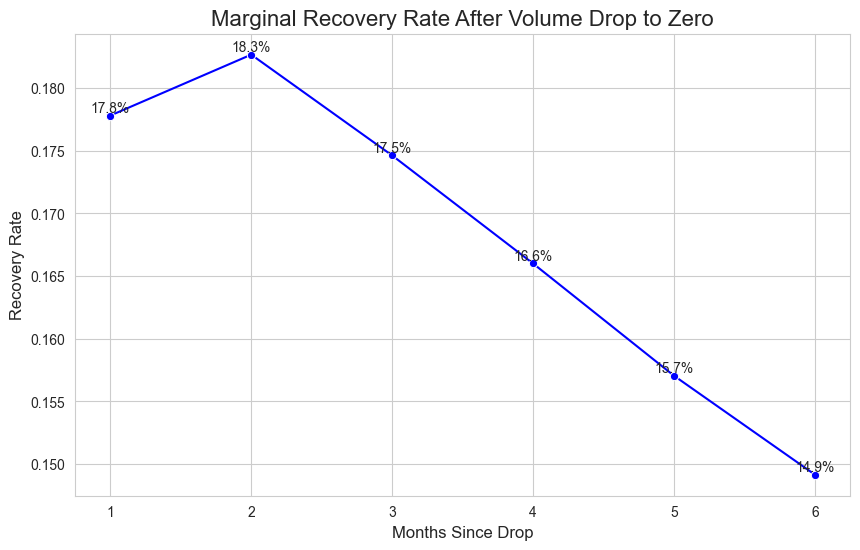

INFO:snowflake.snowpark.session:Closing session: 14816483328227138
INFO:snowflake.snowpark.session:Canceling all running queries
INFO:snowflake.connector.connection:closed
INFO:snowflake.connector.connection:No async queries seem to be running, deleting session
INFO:snowflake.snowpark.session:Closed session: 14816483328227138


In [17]:
def run_recovery_analysis():
    """
    Analyzies the recovery rate of the entities after a drop to zero volume.
    """

    from snowflake.snowpark import Window
    import snowflake.snowpark.functions as F

    # 1. Connection and Data Retrieval
    session = get_snowpark_session()
    source_table = "WORKSPACE.digitalda_stage.ML_Attrition_Master_Table"
    print(f"Connecting to Snowflake and retrieving data from {source_table}...")

    # Load historial volume data
    df_vol = session.table(source_table).select(
        "ORG_URI",
        "COHORT_MONTH",
        "ENT_GALLONS")
    
    # 2. Identify "Drop Events" (Month T)
    # Define window to detect the first month of zero volume after having activity
    window_spec = Window.partition_by("ORG_URI").order_by("COHORT_MONTH")
    df_lags = df_vol.with_column("PREV_GALLONS", F.lag("ENT_GALLONS").over(window_spec))

    # Filter for entities that dropped from >0 to 0 gallons
    df_drops = df_lags.filter((F.col("PREV_GALLONS") > 0) & (F.col("ENT_GALLONS") == 0))

    # 3. Track Recovery (Months T+1 to T+6)
    df_drop_cohorts = df_drops.select(
        F.col("ORG_URI").alias("DROP_ORG"),
        F.col("COHORT_MONTH").alias("DROP_MONTH")
    )

    # Join with future months to track recovery
    df_future = df_vol.join(
        df_drop_cohorts,
       (df_vol["ORG_URI"] == df_drop_cohorts["DROP_ORG"]) &
       (df_vol["COHORT_MONTH"] > df_drop_cohorts["DROP_MONTH"])
    )

    # Calculate months since drop and recovery status
    df_future = df_future.with_column(
        "MONTHS_SINCE_DROP",
        F.datediff("month", F.col("DROP_MONTH"), F.col("COHORT_MONTH")))
    df_future = df_future.filter(F.col("MONTHS_SINCE_DROP") <= 6)

    # 4. Aggregate Recovery Rates
    # Count unique entities that recovered (spent > 0) in each month since drop
    # We use cumulative recovery to see how many have recovered by each month
    df_stats = df_future.groupBy("MONTHS_SINCE_DROP").agg(
        F.count_distinct(F.when(F.col("ENT_GALLONS") > 0, F.col("DROP_ORG"))).alias("RECOVERED_ENTITIES"),
    ).to_pandas()

    total_drops = df_drop_cohorts.count()
    df_stats["CUMULATIVE_RECOVERY_RATE"] = df_stats["RECOVERED_ENTITIES"] / total_drops
    df_stats = df_stats.sort_values("MONTHS_SINCE_DROP")

    # 5. Visualization
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    # Plot the recovery curve
    sns.lineplot(data=df_stats, x="MONTHS_SINCE_DROP", y="CUMULATIVE_RECOVERY_RATE", marker="o", color="blue")

    # Add percentage labels on the points
    for x, y in zip(df_stats["MONTHS_SINCE_DROP"], df_stats["CUMULATIVE_RECOVERY_RATE"]):
        plt.text(x, y, f"{y:.1%}", ha='center', va='bottom', fontsize=10)

    plt.title("Marginal Recovery Rate After Volume Drop to Zero", fontsize=16)
    plt.xlabel("Months Since Drop", fontsize=12)
    plt.ylabel("Recovery Rate", fontsize=12)

    plt.show()
    session.close()


run_recovery_analysis()


## 🧠 3. Feature Engineering & Preprocessing
Validate that the `AttritionFeatureEngineer` correctly handles scaling and encoding.

In [6]:
fe = AttritionFeatureEngineer()
X, y = fe.preprocess_data(df)
print(f"Features defined: {len(fe.feature_cols)}")
X.head()

Features defined: 6


,ENT_GALLONS_VELOCITY_3V12,IS_TRUCKING_INDUSTRY,ACCOUNT_COUNT,ENT_CASE_TOTAL_LAG2,ENT_FEES_LAG1,IS_SMALL_BIZ
0,1.061427,0,1,0.0,10.0,1
1,1.076109,0,1,0.0,10.0,1
2,1.036854,0,1,0.0,10.0,1
3,0.932724,0,1,0.0,10.0,1
4,0.904116,0,1,0.0,10.0,1


## 🚀 4. End-to-End Training
Run the full pipeline to train the model and generate artifacts.

In [7]:
train_all_models("8M", exclude_csv="attrition_pipeline\data\Feb25_Mar25_FlickeringEntities.csv")
print("✅ Pipeline execution complete. Check artifacts/ folder for model and plots.")

INFO:train_model:Starting training pipeline for 8M horizon, attrition type: HARD attrition...
INFO:snowflake.connector.connection:Snowflake Connector for Python Version: 3.14.0, Python Version: 3.8.0, Platform: Windows-10-10.0.26100-SP0
INFO:snowflake.connector.connection:Connecting to GLOBAL Snowflake domain
INFO:snowflake.connector.connection:This connection is in OCSP Fail Open Mode. TLS Certificates would be checked for validity and revocation status. Any other Certificate Revocation related exceptions or OCSP Responder failures would be disregarded in favor of connectivity.
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseFailedToConnectCacheServer|OCSPResponseFetchException', 'sfcPeerHost': 'bqa07840.us-west-2.privatelink.snowflakecomputing.com', 'certId': 'MEcwBwYFKw4DAhoEFKfEuLPcW7VYHqfX8TrFafVvSNeJBBR0hYDAZsffN97PvSk3qgMdvu3NFwIQDTE9kLe5RBNwiIraRbCgwQ==', 'ocspRequestBase64': 'ME8wTTBLMEkwRzAHBgUrDgMCGgQUp8

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://myapps.wexinc.com/app/snowflake/exkaea789nRrm6HV7357/sso/saml?SAMLRequest=pZNLc9owFIX%2FikddYwnHvDSYjBsmhTYkFAyddqfYgiiWJUdXxpBfH5lHJ10km854YUvn6jv3Hnl4vS%2Bkt%2BMGhFYRavsEeVylOhNqG6FVctvqIw8sUxmTWvEIHTig69EQWCFLGlf2SS34S8XBeu4gBbTZiFBlFNUMBFDFCg7UpnQZz%2B5o4BPKALixDofOJRkIx3qytqQY13Xt11e%2BNlscEEIwGWCnaiRf0DtE%2BTmjNNrqVMtLyd719AGijUnYIJzCEebnwq9CnUbwGeXxJAI6SZJ5a%2F6wTJAXX7q70QqqgpslNzuR8tXi7mQAnIPHF0Z6%2FZD4FbRqN7tW4JdG7JjlUqjcB6XrjWQ5T3VRVtYhfPeGNzzDUm%2BFG9x0HKEyF5n89bsm1eu39Hlw6G4ebD9Zv6rQ%2FIjL%2B3zLV%2FlzPPv5fcnYfDJLkbe%2BxBw0MU8BKj5VTbjWLZGg2yLuCZJ2n4ZdGg78Ttj5g7yxMygUs8fKSwfFgZUl%2BDXfC5Ue3blv%2FNc45vuccdbrD9TCFN3JunfV6WEAjZvw0On%2B0KMDM%2FqvqQzx%2B6PO9%2FLeRTUdz7UU6cG71aZg9uMk2377uCKy1uYopbxgQsZZZjiAS1RKXd8Y7nxEyJqKIzw6Uf%

INFO:snowflake.snowpark.session:Snowpark Session information: 
"version" : 1.22.1,
"python.version" : 3.8.0,
"python.connector.version" : 3.14.0,
"python.connector.session.id" : 14816483402053174,
"os.name" : Windows

INFO:data_loader:Successfully connected to Snowflake as W515059
INFO:data_loader:Loading data from WORKSPACE.digitalda_stage.ML_Model_Features_C5...
INFO:train_model:Data Filtering: Removed 10309978 rows. Clean set: 17477051 rows.
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseFailedToConnectCacheServer|OCSPResponseFetchException', 'sfcPeerHost': 'sfc-prod2-ds1-18-customer-stage.s3.us-west-2.amazonaws.com', 'certId': 'MEcwBwYFKw4DAhoEFKF1UQWdIRDSAbkIG3Mzjxw8x71fBBSBuA5jiokSGOX6OztQlZ/m5ZAThQIQCd8qwlDJcSCxEfK48eVFkQ==', 'ocspRequestBase64': 'ME8wTTBLMEkwRzAHBgUrDgMCGgQUoXVRBZ0hENIBuQgbczOPHDzHvV8EFIG4DmOKiRIY5fo7O1CVn+blkBOFAhAJ3yrCUMlxILER8rjx5UWR', 'ocspResponderURL': 'http://ocsp.r2m01.amazontrust.

[LightGBM] [Info] Number of positive: 75964, number of negative: 6868097
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.309138 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2503
[LightGBM] [Info] Number of data points in the train set: 6944061, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010939 -> initscore=-4.504383
[LightGBM] [Info] Start training from score -4.504383
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

INFO:train_model:Model Results [HARD Attrition, Horizon: 8M]: AUC-ROC = 0.7170, AUC-PR = 0.0439
INFO:train_model:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99   1716980
           1       0.00      0.00      0.00     19144

    accuracy                           0.99   1736124
   macro avg       0.49      0.50      0.50   1736124
weighted avg       0.98      0.99      0.98   1736124

INFO:train_model:Generating lift chart...
INFO:train_model:Saved model and feature engineer to attrition_pipeline/artifacts
INFO:train_model:Starting training pipeline for 8M horizon, attrition type: SILENT attrition...
INFO:snowflake.connector.connection:Snowflake Connector for Python Version: 3.14.0, Python Version: 3.8.0, Platform: Windows-10-10.0.26100-SP0
INFO:snowflake.connector.connection:Connecting to GLOBAL Snowflake domain
INFO:snowflake.connector.connection:This connection is in OCSP Fail Open Mode. TLS Certificates would be checked for valid

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://myapps.wexinc.com/app/snowflake/exkaea789nRrm6HV7357/sso/saml?SAMLRequest=pZPNbuIwFEZfJfKsYzuhQGoRKqaoKhpaEH%2BVunMTBzw4dvB1Gnj7MaGMOot2M1IWiX2ufXw%2FZ3B3LFXwLixIo1MUYYoCoTOTS71N0Xr1ECYoAMd1zpXRIkUnAehuOABeqoqNarfTC3GoBbjAL6SBtRMpqq1mhoMEpnkpgLmMLUdPUxZjyiprnMmMQp9Kvq%2FgAMI6b3gtyUF6vZ1zFSOkaRrcdLCxWxJTSgm9JZ46Iz%2Bu%2FNGf6Qs%2BIvTmzHvC4%2FMPt59SX1rwndbbBQL2uFrNw%2FlsuULB6Kp6bzTUpbBLYd9lJtaL6UUAvMHbgdN%2BckNxDWHjexfGuLLynTuhpN5j0KYpFN%2BLzJRV7fwW2L%2BRQuREma30XZiMU1TtZd7lxWj90tssfi1%2Fb2e82fR3vDiUmz19tU%2BLWf4y75TTeDIu8nWGgs015vgc8wSgFhN9Dtf5IRr3QuqfeBUlrNtjUYI7CX1FwdgLSs1dW3k9QXniVQW4EUeps9bOf5O%2F4kQc91zwfnKrF7bsPW76nW6fABhyDhtd7g9rDezwv7oyIJ%2BX%2BriXzz6qyXhulMxOwYOxJXdfJxnhqB2ReVi0KBMll2qU51YA%2BESVMs29Fd4jRc7WApHhZdd%2Ff4DhHw%3D

INFO:snowflake.snowpark.session:Snowpark Session information: 
"version" : 1.22.1,
"python.version" : 3.8.0,
"python.connector.version" : 3.14.0,
"python.connector.session.id" : 14816483402088514,
"os.name" : Windows

INFO:data_loader:Successfully connected to Snowflake as W515059
INFO:data_loader:Loading data from WORKSPACE.digitalda_stage.ML_Model_Features_C5...
INFO:train_model:Data Filtering: Removed 10309978 rows. Clean set: 17477051 rows.
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseFailedToConnectCacheServer|OCSPResponseFetchException', 'sfcPeerHost': 'sfc-prod2-ds1-18-customer-stage.s3.us-west-2.amazonaws.com', 'certId': 'MEcwBwYFKw4DAhoEFKF1UQWdIRDSAbkIG3Mzjxw8x71fBBSBuA5jiokSGOX6OztQlZ/m5ZAThQIQCd8qwlDJcSCxEfK48eVFkQ==', 'ocspRequestBase64': 'ME8wTTBLMEkwRzAHBgUrDgMCGgQUoXVRBZ0hENIBuQgbczOPHDzHvV8EFIG4DmOKiRIY5fo7O1CVn+blkBOFAhAJ3yrCUMlxILER8rjx5UWR', 'ocspResponderURL': 'http://ocsp.r2m01.amazontrust.

[LightGBM] [Info] Number of positive: 419725, number of negative: 6524440
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.372410 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3266
[LightGBM] [Info] Number of data points in the train set: 6944165, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.060443 -> initscore=-2.743711
[LightGBM] [Info] Start training from score -2.743711
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

INFO:train_model:Model Results [SILENT Attrition, Horizon: 8M]: AUC-ROC = 0.8082, AUC-PR = 0.2549
INFO:train_model:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97   1631270
           1       0.54      0.02      0.03    104750

    accuracy                           0.94   1736020
   macro avg       0.74      0.51      0.50   1736020
weighted avg       0.92      0.94      0.91   1736020

INFO:train_model:Generating lift chart...
INFO:train_model:Saved model and feature engineer to attrition_pipeline/artifacts


✅ Pipeline execution complete. Check artifacts/ folder for model and plots.


## 5. Pipeline Step: Batch Inference for Latest Snapshot
In this phase, we use the trained baseline model to score the most recent cross-section of data in the master table (`COHORT_MONTH`). It applies identical preprocessing logic via the cached `FeatureEngineer` and outputs the final probabilities to the artifacts directory.


In [3]:
import os
import pandas as pd
from predict_model import predict_latest_snapshot  

# 1. Define paths
output_data_dir = os.environ.get('SM_OUTPUT_DATA_DIR', 'attrition_pipeline/artifacts')
preds_path = os.path.join(output_data_dir, 'predictions_latest_8M.csv')

# 2. FORCE EXECUTION (Call the inference function before reading)
print(f"🚀 Starting inference pipeline to update predictions...")
try:
    # This calls your function defined in the script to pull data and score it
    predict_latest_snapshot(horizon="8M")
    print("✅ Inference complete and file updated.")
except Exception as e:
    print(f"❌ Error during inference: {e}")

# 3. Load the results (now refreshed)
print(f"\n--- Loading Inference Results from {preds_path} ---")
if os.path.exists(preds_path):
    preds_df = pd.read_csv(preds_path)
    print(f"✅ Loaded {len(preds_df)} prediction records.")
    
    # Show the updated top 10 highest-risk entities
    display(preds_df.head(10))
else:
    print("❌ Predictions file not found even after execution attempt.")


INFO:predict_model:Starting inference pipeline for 8M horizon on latest snapshot...
INFO:snowflake.connector.connection:Snowflake Connector for Python Version: 3.14.0, Python Version: 3.8.0, Platform: Windows-10-10.0.26100-SP0
INFO:snowflake.connector.connection:Connecting to GLOBAL Snowflake domain
INFO:snowflake.connector.connection:This connection is in OCSP Fail Open Mode. TLS Certificates would be checked for validity and revocation status. Any other Certificate Revocation related exceptions or OCSP Responder failures would be disregarded in favor of connectivity.


🚀 Starting inference pipeline to update predictions...


 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseFailedToConnectCacheServer|OCSPResponseFetchException', 'sfcPeerHost': 'bqa07840.us-west-2.privatelink.snowflakecomputing.com', 'certId': 'MEcwBwYFKw4DAhoEFKfEuLPcW7VYHqfX8TrFafVvSNeJBBR0hYDAZsffN97PvSk3qgMdvu3NFwIQDTE9kLe5RBNwiIraRbCgwQ==', 'ocspRequestBase64': 'ME8wTTBLMEkwRzAHBgUrDgMCGgQUp8S4s9xbtVgep9fxOsVp9W9I14kEFHSFgMBmx9833s+9KTeqAx2+7c0XAhANMT2Qt7lEE3CIitpFsKDB', 'ocspResponderURL': 'http://ocsp.digicert.com', 'errorMessage': "254003: 254003: Could not fetch OCSP Response from server. Considerchecking your whitelists : Exception - ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))", 'insecureMode': False, 'failOpen': True, 'cacheEnabled': True, 'cacheHit': False}
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPR

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://myapps.wexinc.com/app/snowflake/exkaea789nRrm6HV7357/sso/saml?SAMLRequest=pZNLj9owFIX%2FSuSuEzuE8rAIIwY0Q6ppG%2FGYaroziQELxw6%2BDoF%2FXydANV3MbCplkdj3%2Bjv3HGf0cC6kd%2BIGhFYxCgOCPK4ynQu1i9F69eQPkAeWqZxJrXiMLhzQw3gErJAlnVR2rxb8WHGwnjtIAW02YlQZRTUDAVSxggO1GV1Ovr%2FQTkAoA%2BDGOhy6teQgHGtvbUkxrus6qKNAmx3uEEIwGWJX1ZR8Qe8Q5eeM0mirMy3vLWc30weIEJNug3AVjpDeGh%2BFulrwGWVzLQI6X61SP%2F25XCFvcp9uqhVUBTdLbk4i4%2BvFy1UAOAWbIyP9QZcEFfi1887vBKURJ2a5FOoQgNL1VrIDz3RRVtYhAveGtzzHUu%2BEMy6Zxag8iHw6S6v0LXlmJ%2Fn8dlDHeTSFsrgUycZ5N6yWj9%2Fs%2Ftcgmu7XdYa813vMnSbmBKDiiWrCtW6JdHo%2BcU%2B0Crs0JDTqBcMw%2FI28mRMoFLNt532C4sLKEoKan4XKWnXuG%2F8Vjvn5wDjrD4ZqYYre%2FLUffe1jAI2b8ND1%2FtBWgRn%2Flysj%2FP6o27384aJKZqmWIrt4T9oUzH6cZBiE7YrI%2FW1bSnnBhJzkueEALlEpdT013OmIkTUVR

INFO:snowflake.snowpark.session:Snowpark Session information: 
"version" : 1.22.1,
"python.version" : 3.8.0,
"python.connector.version" : 3.14.0,
"python.connector.session.id" : 14816483404955038,
"os.name" : Windows

INFO:data_loader:Successfully connected to Snowflake as W515059
INFO:predict_model:Executing C6 Distance/Density SQL Pipeline...


...

INFO:predict_model:Fetching Distance/Density metrics into Pandas...


Successfully executed c:\Users\W515059\Documents\nam_attrition\attrition_pipeline\sql\c6_distance_density.sql


 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseFailedToConnectCacheServer|OCSPResponseFetchException', 'sfcPeerHost': 'sfc-prod2-ds1-18-customer-stage.s3.us-west-2.amazonaws.com', 'certId': 'MEcwBwYFKw4DAhoEFKF1UQWdIRDSAbkIG3Mzjxw8x71fBBSBuA5jiokSGOX6OztQlZ/m5ZAThQIQCd8qwlDJcSCxEfK48eVFkQ==', 'ocspRequestBase64': 'ME8wTTBLMEkwRzAHBgUrDgMCGgQUoXVRBZ0hENIBuQgbczOPHDzHvV8EFIG4DmOKiRIY5fo7O1CVn+blkBOFAhAJ3yrCUMlxILER8rjx5UWR', 'ocspResponderURL': 'http://ocsp.r2m01.amazontrust.com', 'errorMessage': "254003: 254003: Could not fetch OCSP Response from server. Considerchecking your whitelists : Exception - ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))", 'insecureMode': False, 'failOpen': True, 'cacheEnabled': True, 'cacheHit': False}
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSu

✅ Inference complete and file updated.

--- Loading Inference Results from attrition_pipeline/artifacts\predictions_latest_8M.csv ---
✅ Loaded 318871 prediction records.


,ORG_URI,COHORT_MONTH,ACCOUNT_COUNT,STATUS_ACTIVE_COUNT,ACCOUNT_DETAILS_LIST,HAS_INELIGIBLE_ACCOUNT,CONTACT_ACCOUNT_ID,CONTACT_SELECTION_RULE,TOTAL_GALLONS_LAST_MONTH,TOTAL_SPEND_LAST_MONTH,...,TERTIARY_ATTRITION_REASON,PRIMARY_ATTRITION_CATEGORY,EXPECTED_GALLONS_AT_RISK,EXPECTED_SPEND_AT_RISK,SCORE_DELTA,IS_RAPID_ESCALATION,JOURNEY_ID,JOURNEY_CHANNEL,JOURNEY_TREATMENT,PREDICTION_RANK_COMBINED
0,entities/j4ymTwd,2026-04-01,2,2,"[{""account_id"": ""9100000768132"", ""credit_risk_...",True,9100000768132,R2,158837.294,664378.23,...,Declining Fuel Volume Trend,Fee Related,49729.666336,208007.243555,NaN,0,T1-FEE,HIGH_PRIORITY_CALL,Senior outreach + fee waiver or AutoPay migrat...,1
1,entities/CFCw2Mp,2026-04-01,2,1,"[{""account_id"": ""9100014329989"", ""credit_risk_...",True,9100014329989,R5,72048.496,274979.43,...,Declining Fuel Volume Trend,Fee Related,10438.262816,39838.549294,NaN,0,T1-FEE,HIGH_PRIORITY_CALL,Senior outreach + fee waiver or AutoPay migrat...,2
2,entities/4fqsW8X,2026-04-01,36,30,"[{""account_id"": ""9100014515731"", ""credit_risk_...",True,9100014515704,R3,58182.844,313604.29,...,Fuel Volume Declining Year-over-Year,Fuel Volume / Purchasing,10861.714959,58544.412301,NaN,0,T1-USAGE,EMAIL_PLUS_SURVEY,Value reinforcement campaign + satisfaction su...,3
3,entities/3nGBqgo,2026-04-01,6,5,"[{""account_id"": ""9100003245148"", ""credit_risk_...",True,9100003245148,R5,51459.576,250182.74,...,Reduced Fleet Activity (Past 12 Months),Fuel Volume / Purchasing,7460.245354,36269.724096,NaN,0,T1-USAGE,EMAIL_PLUS_SURVEY,Value reinforcement campaign + satisfaction su...,4
4,entities/3bDRY5z,2026-04-01,23,22,"[{""account_id"": ""9100012362166"", ""credit_risk_...",True,9100012362166,R5,44505.941,177391.21,...,Fuel Volume Declining Year-over-Year,Fuel Volume / Purchasing,11047.709392,44033.818693,NaN,0,T1-USAGE,EMAIL_PLUS_SURVEY,Value reinforcement campaign + satisfaction su...,5
5,entities/3LRFdQk,2026-04-01,1,1,"[{""account_id"": ""9100007294833"", ""credit_risk_...",True,9100007294833,R1,44003.845,289066.29,...,High CS Contact Rate Relative to Fuel Volume,Fuel Volume / Purchasing,6773.182589,44493.810996,NaN,0,T1-USAGE,EMAIL_PLUS_SURVEY,Value reinforcement campaign + satisfaction su...,6
6,entities/86dOqJk,2026-04-01,2,2,"[{""account_id"": ""9100014746779"", ""credit_risk_...",True,9100014746779,R2,35603.149,155454.13,...,Real-time Fuel Card Declined Spike,Fuel Volume / Purchasing,5320.674736,23231.677124,NaN,0,T1-USAGE,EMAIL_PLUS_SURVEY,Value reinforcement campaign + satisfaction su...,7
7,entities/4cZzJjR,2026-04-01,1,1,"[{""account_id"": ""9100008761194"", ""credit_risk_...",True,9100008761194,R1,32989.615,162577.57,...,Fee Burden Increasing Over Time,Fuel Volume / Purchasing,5021.862258,24748.459867,NaN,0,T1-USAGE,EMAIL_PLUS_SURVEY,Value reinforcement campaign + satisfaction su...,8
8,entities/7drseMR,2026-04-01,1,1,"[{""account_id"": ""9100011699721"", ""credit_risk_...",True,9100011699721,R1,32967.727,172934.25,...,Escalating Customer Service Activity,Fuel Volume / Purchasing,5663.460452,29708.031911,NaN,0,T1-USAGE,EMAIL_PLUS_SURVEY,Value reinforcement campaign + satisfaction su...,9
9,entities/35229BH,2026-04-01,3,1,"[{""account_id"": ""9100003077181"", ""credit_risk_...",True,9100013950810,R4,28260.140,134505.84,...,Reduced Fleet Activity (Past 12 Months),Fuel Volume / Purchasing,4151.490204,19759.267901,NaN,0,T1-USAGE,EMAIL_PLUS_SURVEY,Value reinforcement campaign + satisfaction su...,10


## 🧠 6. Seasonality Check


INFO:snowflake.connector.connection:Snowflake Connector for Python Version: 3.14.0, Python Version: 3.8.0, Platform: Windows-10-10.0.26100-SP0
INFO:snowflake.connector.connection:Connecting to GLOBAL Snowflake domain
INFO:snowflake.connector.connection:This connection is in OCSP Fail Open Mode. TLS Certificates would be checked for validity and revocation status. Any other Certificate Revocation related exceptions or OCSP Responder failures would be disregarded in favor of connectivity.
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseFailedToConnectCacheServer|OCSPResponseFetchException', 'sfcPeerHost': 'bqa07840.us-west-2.privatelink.snowflakecomputing.com', 'certId': 'MEcwBwYFKw4DAhoEFKfEuLPcW7VYHqfX8TrFafVvSNeJBBR0hYDAZsffN97PvSk3qgMdvu3NFwIQDTE9kLe5RBNwiIraRbCgwQ==', 'ocspRequestBase64': 'ME8wTTBLMEkwRzAHBgUrDgMCGgQUp8S4s9xbtVgep9fxOsVp9W9I14kEFHSFgMBmx9833s+9KTeqAx2+7c0XAhANMT2Qt7lEE3CIitpFsKDB', 'ocspResponde

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://myapps.wexinc.com/app/snowflake/exkaea789nRrm6HV7357/sso/saml?SAMLRequest=pZNbb%2BIwEIX%2FSuR9TuyEuwVULKgiqNsioBXbN5MM1Epipx6ngX%2B%2FDpdV96F92TfHOePvzBx7eHcscu8DDEqtRiQMGPFAJTqV6jAiz5t7v088tEKlItcKRuQESO7GQxRFXvJJZd%2FUCt4rQOu5gxTy5seIVEZxLVAiV6IA5Dbh68mvBx4FjAtEMNbhyLUkRelYb9aWnNK6roO6FWhzoBFjjLIBdapG8oN8QpTfM0qjrU50fis5up6%2BQISUtRuEUzjC8lr4U6rLCL6j7C4i5PPNZukvn9Yb4k1u3U21wqoAswbzIRN4Xj1cDKBzsHsXrNdvs6BCv3az86OgNPJDWMilygJUut7nIoNEF2VlHSJwK7qHlOb6IN3g4tmIlJlM63S6jc28XGxT8bu7WE%2Bz5JiWp8U%2Bhqf9fFpsV5Fhr0XY32UJ8V5uMUdNzDFiBbFqwrVui0Vdn3X8qLsJW7zV4u1B0GHhK%2FFmzqBUwp4rbx0UJ1GWGNRwlCo5u3Pf9K9xCsdMgOj1B2pliu78pdfq9Ciipk145HJ%2F%2BNmBGf%2FXVIb081HXe%2FnooopnS53L5OTda1MI%2B3WSYRCed2Tq789SDoWQ%2BSRNDSC6RPNc11MDzseIWFMBoeML9d8HMP4D&RelayS

INFO:snowflake.snowpark.session:Snowpark Session information: 
"version" : 1.30.0,
"python.version" : 3.8.0,
"python.connector.version" : 3.14.0,
"python.connector.session.id" : 14816483375981462,
"os.name" : Windows

INFO:data_loader:Successfully connected to Snowflake as W515059
INFO:data_loader:Loading data from WORKSPACE.digitalda_stage.ML_Model_Features_C5...
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseFailedToConnectCacheServer|OCSPResponseFetchException', 'sfcPeerHost': 'sfc-prod2-ds1-18-customer-stage.s3.us-west-2.amazonaws.com', 'certId': 'MEcwBwYFKw4DAhoEFKF1UQWdIRDSAbkIG3Mzjxw8x71fBBSBuA5jiokSGOX6OztQlZ/m5ZAThQIQCd8qwlDJcSCxEfK48eVFkQ==', 'ocspRequestBase64': 'ME8wTTBLMEkwRzAHBgUrDgMCGgQUoXVRBZ0hENIBuQgbczOPHDzHvV8EFIG4DmOKiRIY5fo7O1CVn+blkBOFAhAJ3yrCUMlxILER8rjx5UWR', 'ocspResponderURL': 'http://ocsp.r2m01.amazontrust.com', 'errorMessage': "254003: 254003: Could not fetch OCSP Response from server. 

🛑 Missing features the model needs: set()


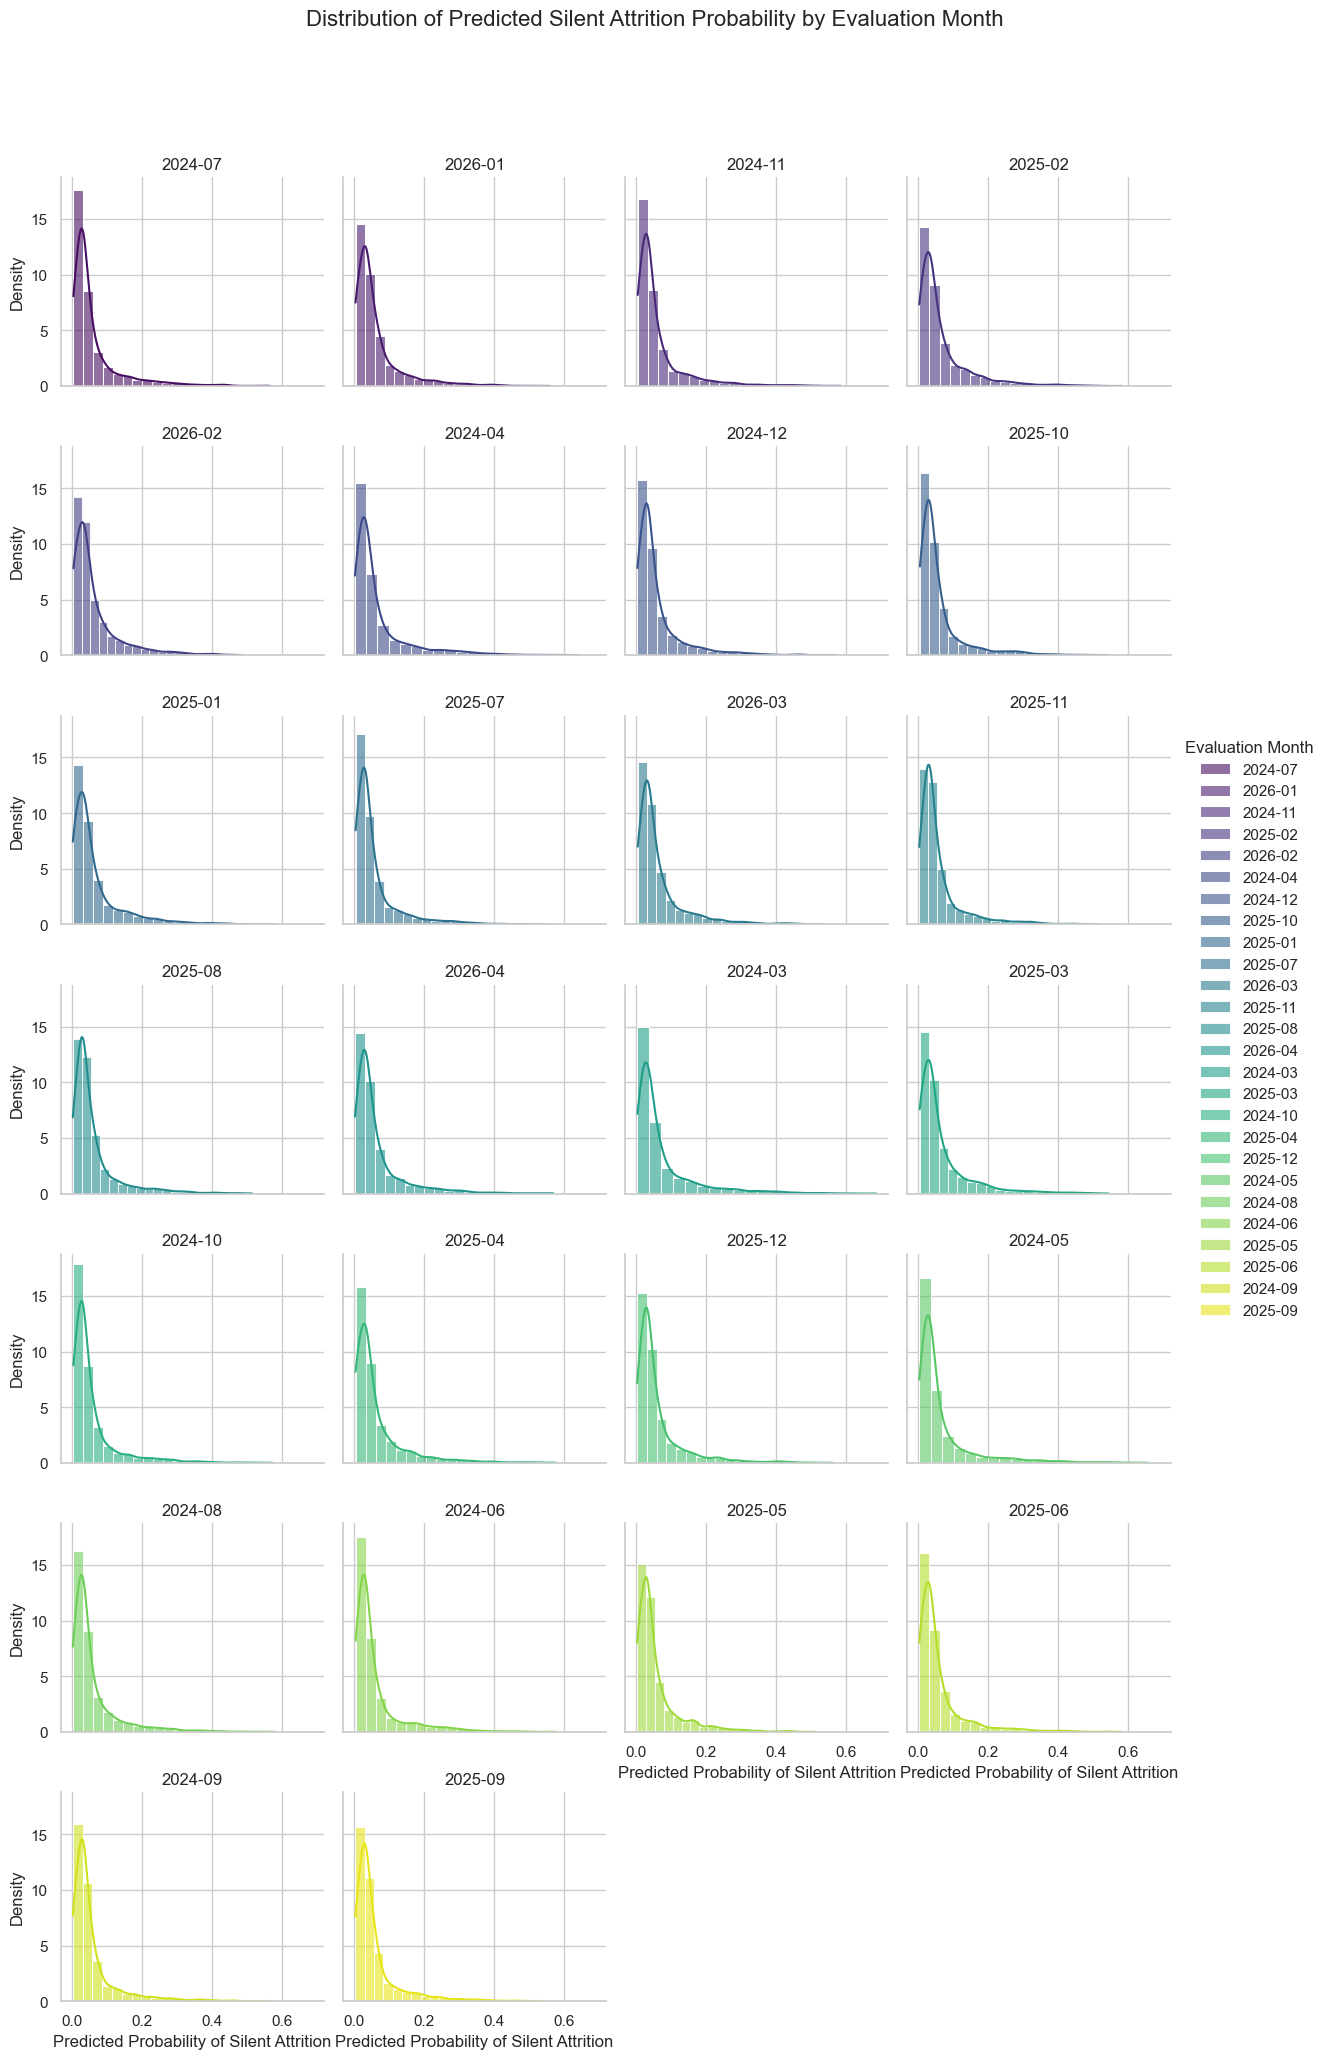

In [4]:
import os
import pathlib

# --- WINDOWS COMPATIBILITY PATCH FOR SNOWPARK ---
_orig_is_file = pathlib.Path.is_file
def _patched_is_file(self):
    try:
        str_path = str(self)
        if "<" in str_path or ">" in str_path:
            return False
        return _orig_is_file(self)
    except Exception:
        return False
pathlib.Path.is_file = _patched_is_file

os.environ["SNOWPARK_SKIP_SOURCE_CODE_COLLECTION"] = "True"
# ------------------------------------------------

import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import snowflake.snowpark.functions as F
from data_loader import get_snowpark_session, load_training_data

# ... el resto de tu código igual ...

session = get_snowpark_session()

snowpark_df = load_training_data(session, table_name="WORKSPACE.digitalda_stage.ML_Model_Features_C5")

model_dir = "attrition_pipeline/artifacts"
with open(os.path.join(model_dir, "model_SILENT.pkl"), "rb") as f:
    model_silent = pickle.load(f)

with open(os.path.join(model_dir, "feature_engineer_SILENT.pkl"), "rb") as f:
    fe_silent = pickle.load(f)

# Aplicar filtros
snowpark_df = snowpark_df.filter(
    (F.col('EXCL_FLAG_1') == 0)
    & (F.col("EXCL_FLAG_2") == 0)
    & (F.col("EXCL_FLAG_HIST_15M") == 0)
)

snowpark_df = snowpark_df.sample(frac=0.01)  # Muestra aleatoria del 1% para pruebas rápidas

df_raw = snowpark_df.to_pandas()

# Preprocesamiento y predicción
X = fe_silent.preprocess_data(df_raw, is_training=False)

# Chequeo de variables perdidas
expected_features = set(model_silent.feature_name_)
current_features = set(X.columns)
missing_in_inference = expected_features - current_features

print(f"🛑 Missing features the model needs: {missing_in_inference}")

df_eval = df_raw.loc[X.index].copy()
df_eval['PROB_SILENT'] = model_silent.predict_proba(X)[:, 1]

col_month = "COHORT_MONTH" if "COHORT_MONTH" in df_eval.columns else "cohort_month"

df_eval['EVAL_MONTH_STR'] = df_eval[col_month].dt.strftime('%Y-%m')

months_sorted = sorted(df_eval['EVAL_MONTH_STR'].unique())

sns.set_theme(style="whitegrid")
sns.color_palette("viridis", len(months_sorted))

g = sns.FacetGrid(df_eval, col="EVAL_MONTH_STR", hue="EVAL_MONTH_STR", col_wrap=4, sharex=True, sharey=True, row_order=months_sorted, palette="viridis")
g.map(sns.histplot, "PROB_SILENT", bins=20, kde=True, stat="density", alpha=0.6)
g.set_axis_labels("Predicted Probability of Silent Attrition", "Density")
g.set_titles(col_template="{col_name}")
g.add_legend(title="Evaluation Month")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Distribution of Predicted Silent Attrition Probability by Evaluation Month", fontsize=16)
plt.show()